# Feature Selection Playground

This notebook analyzes all available features in the `Track` class to determine which are most predictive of Cue Points.
It performs:
1. Bulk Feature Extraction (including all scalars and vectors)
2. Missing Value Analysis
3. Feature Distribution Comparisons (Cues vs Non-Cues)
4. LightGBM Feature Importance Ranking

In [1]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from pathlib import Path
from tqdm.auto import tqdm

sys.path.append('..')
from track import Track

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data
Load processed `.pkl` files.

In [2]:
data_dir = Path("../../data/processed")
pkl_files = list(data_dir.glob("*.pkl"))

print(f"Found {len(pkl_files)} processed tracks.")

tracks = []
for pkl_path in pkl_files:
    try:
        with open(pkl_path, 'rb') as f:
            t = pickle.load(f)
            if t.num_bars > 0:
                tracks.append(t)
    except Exception as e:
        print(f"Error loading {pkl_path.name}: {e}")

print(f"Successfully loaded {len(tracks)} tracks.")

Found 174 processed tracks.
Successfully loaded 174 tracks.


## 2. Comprehensive Feature Extraction

We extract **every** available feature from the `Track` objects into a flat DataFrame (1 row per Bar).
This includes flattening the Chroma vectors (12 dimensions).

In [3]:
from src.features import FeatureExtractor

def extract_all_features(track_list):
    """
    Uses the centralized FeatureExtractor to ensure analysis matches training reality.
    """
    data_frames = []
    
    for t in tqdm(track_list, desc="Extracting Features"):
        # 1. Extract Features (X)
        # This now includes the new Tier 5 (Phrase) and Tier 6 (Flux) features
        df = FeatureExtractor.extract(t)
        
        # 2. Extract Labels (y)
        # We need to manually add these since FeatureExtractor returns them separately normally
        # But for this flattened playground, we want them in one big table.
        # We'll use the internal helper or just recreate the label logic briefly here
        # or better, update FeatureExtractor to have a helper.
        
        # For now, let's just grab the cue indices manually to match the notebook's expectation
        cue_in_idxs = set()
        cue_out_idxs = set()
        if len(t.cue_in) > 0:
            idxs = np.searchsorted(t.bars, t.cue_in)
            idxs = np.clip(idxs, 0, t.num_bars - 1)
            cue_in_idxs.update(idxs)
        if len(t.cue_out) > 0:
            idxs = np.searchsorted(t.bars, t.cue_out)
            idxs = np.clip(idxs, 0, t.num_bars - 1)
            cue_out_idxs.update(idxs)
            
        # Add labels to the DataFrame
        df['is_cue_in'] = df['bar_index'].apply(lambda i: 1 if i in cue_in_idxs else 0)
        df['is_cue_out'] = df['bar_index'].apply(lambda i: 1 if i in cue_out_idxs else 0)
        
        # Add Track-Level metadata that might not be in standard features but useful for analysis
        df['tempo'] = t.tempo
        df['is_minor'] = 1 if (t.key_scale == 'minor') else 0
        df['key_tonic'] = t.key_tonic if t.key_tonic is not None else -1
        
        # Section Names (for display/analysis only)
        # FeatureExtractor gives 'dist_to_section', but here we want names for plotting
        sorted_section_starts = sorted(t.sections.keys()) if t.sections else []
        section_names = []
        current_section = "Unknown"
        for i in range(t.num_bars):
            # Update current section
             # Find closest start <= i
            candidates = [s for s in sorted_section_starts if s <= i]
            if candidates:
                current_section = t.sections[candidates[-1]]
            section_names.append(current_section)
        
        df['section_name'] = section_names

        data_frames.append(df)
            
    return pd.concat(data_frames, ignore_index=True)

if len(tracks) > 0:
    df = extract_all_features(tracks)
    print(f"DataFrame Shape: {df.shape}")
    display(df.head())
    print("Columns available:", df.columns.tolist())
else:
    print("No tracks loaded.")

DataFrame Shape: (15686, 49)


,track_id,bar_index,is_cue_in,is_cue_out,energy,low_band_energy,high_band_energy,mid_band_energy,rms_energy,energy_derivative,...,energy_prev_8,energy_next_8,energy_diff_context,is_4_bar,tempo,duration,key_conf,is_minor,key_tonic,section_name
0,Da Hype (Junior Jack Original Club Mix),0,0,0,45121.871094,42412.902344,1546.932983,1162.036377,0.240165,0.000000,...,45121.871094,44541.562500,-580.308594,1,126.048018,564.964717,0.68269,1,8,Unknown
1,Da Hype (Junior Jack Original Club Mix),1,1,0,44636.796875,41900.187500,1519.819580,1216.784546,0.238218,-485.074219,...,44879.333984,44562.566406,-316.767578,0,126.048018,564.964717,0.68269,1,8,Unknown
2,Da Hype (Junior Jack Original Club Mix),2,0,0,44574.789062,41953.476562,1507.728516,1113.585571,0.237786,-62.007812,...,44777.819010,44792.782552,14.963542,0,126.048018,564.964717,0.68269,1,8,Unknown
3,Da Hype (Junior Jack Original Club Mix),3,0,0,44615.675781,41870.437500,1517.752686,1227.485840,0.237950,40.886719,...,44737.283203,44805.821289,68.538086,0,126.048018,564.964717,0.68269,1,8,Unknown
4,Da Hype (Junior Jack Original Club Mix),4,0,0,44965.046875,42216.855469,1521.914307,1226.277954,0.239831,349.371094,...,44782.835938,48379.858594,3597.022656,1,126.048018,564.964717,0.68269,1,8,Unknown


In [4]:
# --- Post-Processing: One-Hot Encode Sections ---
if 'section_name' in df.columns:
    print("Unique Sections found:", df['section_name'].unique())
    
    # One-hot encode
    df = pd.get_dummies(df, columns=['section_name'], prefix='sec')
    
    print("DataFrame shape after One-Hot Encoding:", df.shape)
    display(df.head())

Unique Sections found: <StringArray>
['Unknown']
Length: 1, dtype: str
DataFrame shape after One-Hot Encoding: (15686, 49)


,track_id,bar_index,is_cue_in,is_cue_out,energy,low_band_energy,high_band_energy,mid_band_energy,rms_energy,energy_derivative,...,energy_prev_8,energy_next_8,energy_diff_context,is_4_bar,tempo,duration,key_conf,is_minor,key_tonic,sec_Unknown
0,Da Hype (Junior Jack Original Club Mix),0,0,0,45121.871094,42412.902344,1546.932983,1162.036377,0.240165,0.000000,...,45121.871094,44541.562500,-580.308594,1,126.048018,564.964717,0.68269,1,8,True
1,Da Hype (Junior Jack Original Club Mix),1,1,0,44636.796875,41900.187500,1519.819580,1216.784546,0.238218,-485.074219,...,44879.333984,44562.566406,-316.767578,0,126.048018,564.964717,0.68269,1,8,True
2,Da Hype (Junior Jack Original Club Mix),2,0,0,44574.789062,41953.476562,1507.728516,1113.585571,0.237786,-62.007812,...,44777.819010,44792.782552,14.963542,0,126.048018,564.964717,0.68269,1,8,True
3,Da Hype (Junior Jack Original Club Mix),3,0,0,44615.675781,41870.437500,1517.752686,1227.485840,0.237950,40.886719,...,44737.283203,44805.821289,68.538086,0,126.048018,564.964717,0.68269,1,8,True
4,Da Hype (Junior Jack Original Club Mix),4,0,0,44965.046875,42216.855469,1521.914307,1226.277954,0.239831,349.371094,...,44782.835938,48379.858594,3597.022656,1,126.048018,564.964717,0.68269,1,8,True


## 3. Data Quality Analysis
Check for missing values. LightGBM can handle NaNs, but if a feature is 90% missing, it might not be useful.

In [5]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    plt.figure(figsize=(10, 5))
    missing.plot(kind='bar')
    plt.title("Percentage of Missing Values per Feature")
    plt.ylabel("% Missing")
    plt.show()

    print("Top missing features:")
    print(missing.head(10))
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


## 4. Feature Selection using LightGBM Feature Importance
We train a Gradient Boosting Model to differentiate between **Cue Points** and **Random Bars**.

The model naturally selects the best features to make splits. We can then visualize the "Gain" or "Split" importance.

**Note**: We treat this as a binary classification problem for feature selection purposes.

analyzing importance for: is_cue_in ...
Positive Samples: 484, Negative Samples: 15202, Weight: 31.41


<Figure size 1000x1200 with 0 Axes>

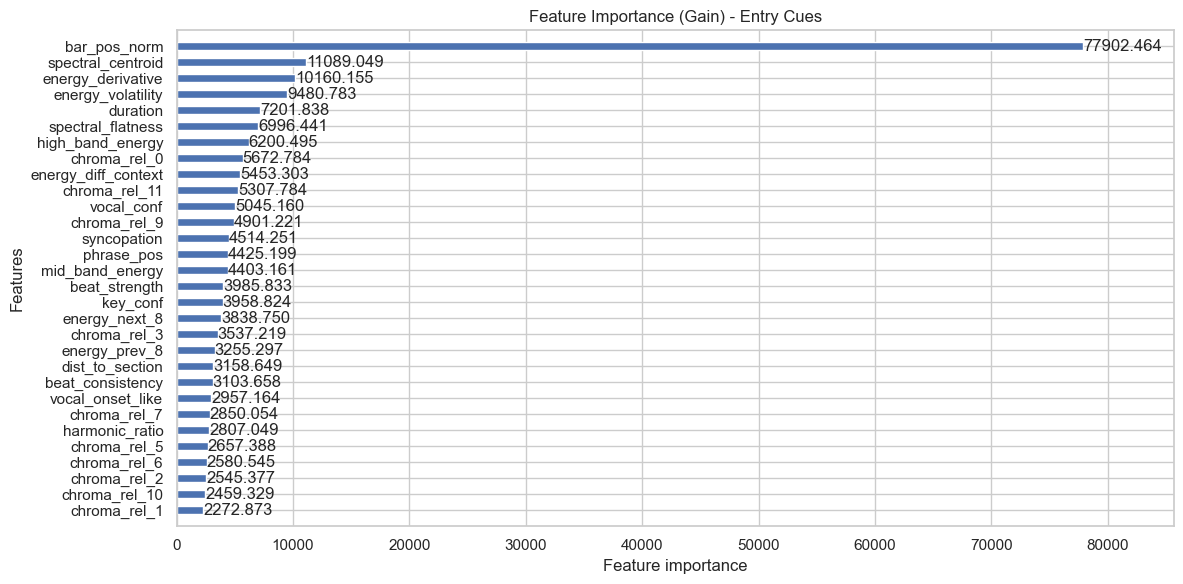


--- Top 20 Features (Entry Cues) ---
            Feature         Gain
       bar_pos_norm 77902.464026
  spectral_centroid 11089.049429
  energy_derivative 10160.154914
  energy_volatility  9480.783010
           duration  7201.838059
  spectral_flatness  6996.441387
   high_band_energy  6200.495394
       chroma_rel_0  5672.784462
energy_diff_context  5453.303253
      chroma_rel_11  5307.783959
         vocal_conf  5045.159690
       chroma_rel_9  4901.220879
        syncopation  4514.251163
         phrase_pos  4425.198520
    mid_band_energy  4403.161067
      beat_strength  3985.833016
           key_conf  3958.823698
      energy_next_8  3838.749866
       chroma_rel_3  3537.218522
      energy_prev_8  3255.297454


In [6]:
def analyze_feature_importance(df, target_col='is_cue_in', title_suffix="Cue In"):
    print(f"analyzing importance for: {target_col} ...")
    
    #Prepare Data
    # Exclude non-feature columns
    drop_cols = ['track_id', 'bar_index', 'is_cue_in', 'is_cue_out']
    
    X = df.drop(columns=drop_cols)
    y = df[target_col]
    
    # Handle Class Imbalance
    # Cues are very rare (<1%). We use scale_pos_weight.
    pos_count = y.sum()
    neg_count = len(y) - pos_count
    scale_weight = neg_count / pos_count if pos_count > 0 else 1.0
    
    print(f"Positive Samples: {pos_count}, Negative Samples: {neg_count}, Weight: {scale_weight:.2f}")
    
    # Train LightGBM
    # Using a relatively simple configuration to capture main effects
    clf = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        scale_pos_weight=scale_weight,
        random_state=42,
        verbose=-1
    )
    
    clf.fit(X, y)
    
    #Plot Importance
    plt.figure(figsize=(10, 12))
    lgb.plot_importance(clf, importance_type='gain', max_num_features=30, height=0.5, title=f'Feature Importance (Gain) - {title_suffix}')
    plt.tight_layout()
    plt.show()

    # Print top features in tabular format
    booster = clf.booster_
    importance = booster.feature_importance(importance_type='gain')
    feature_names = booster.feature_name()
    
    importance_df = pd.DataFrame({'Feature': feature_names, 'Gain': importance})
    importance_df = importance_df.sort_values(by='Gain', ascending=False)
    
    print(f"\n--- Top 20 Features ({title_suffix}) ---")
    print(importance_df.head(20).to_string(index=False))
    
    return clf

model_in = analyze_feature_importance(df, 'is_cue_in', "Entry Cues")

analyzing importance for: is_cue_out ...
Positive Samples: 436, Negative Samples: 15250, Weight: 34.98


<Figure size 1000x1200 with 0 Axes>

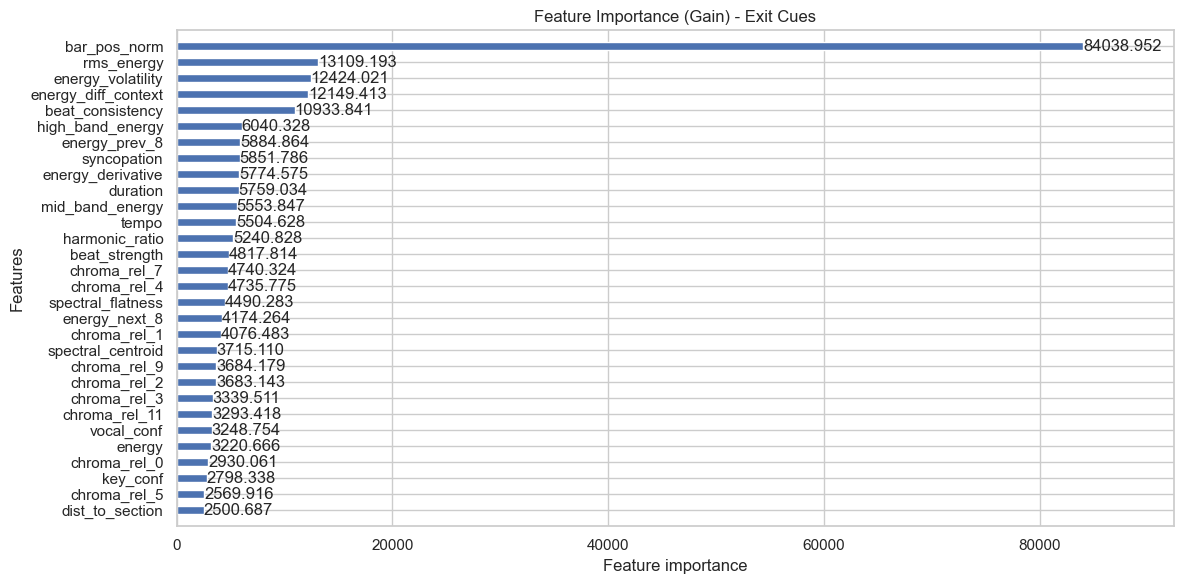


--- Top 20 Features (Exit Cues) ---
            Feature         Gain
       bar_pos_norm 84038.952312
         rms_energy 13109.193332
  energy_volatility 12424.020631
energy_diff_context 12149.413210
   beat_consistency 10933.841395
   high_band_energy  6040.327683
      energy_prev_8  5884.863731
        syncopation  5851.785610
  energy_derivative  5774.575162
           duration  5759.033975
    mid_band_energy  5553.846525
              tempo  5504.628293
     harmonic_ratio  5240.827658
      beat_strength  4817.814451
       chroma_rel_7  4740.324411
       chroma_rel_4  4735.775009
  spectral_flatness  4490.283464
      energy_next_8  4174.264009
       chroma_rel_1  4076.482676
  spectral_centroid  3715.110116


In [7]:
model_out = analyze_feature_importance(df, 'is_cue_out', "Exit Cues")

## 5. Visualizing Top Features
Let's look closer at the distributions of the top features identified above.

Top features for is_cue_in: ['bar_pos_norm', 'spectral_centroid', 'energy_derivative', 'energy_volatility', 'duration', 'spectral_flatness']


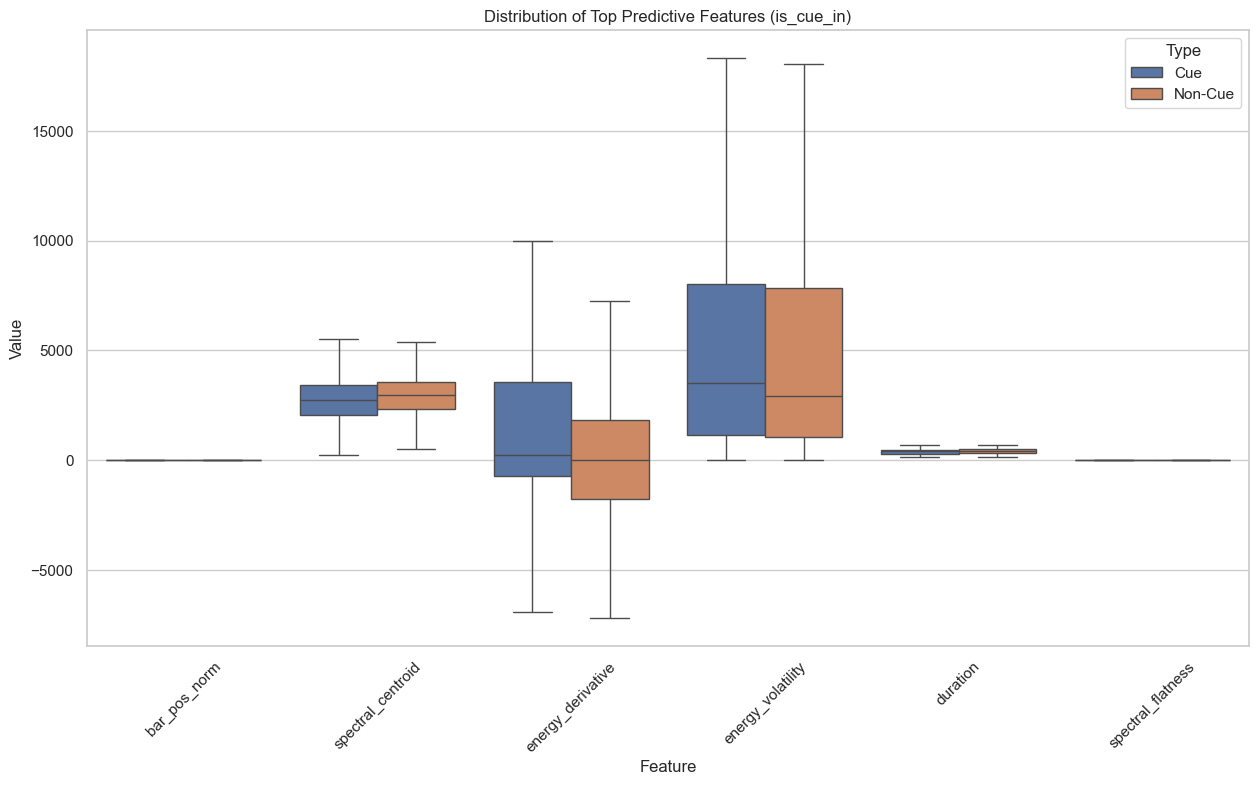

Top features for is_cue_out: ['bar_pos_norm', 'rms_energy', 'energy_volatility', 'energy_diff_context', 'beat_consistency', 'high_band_energy']


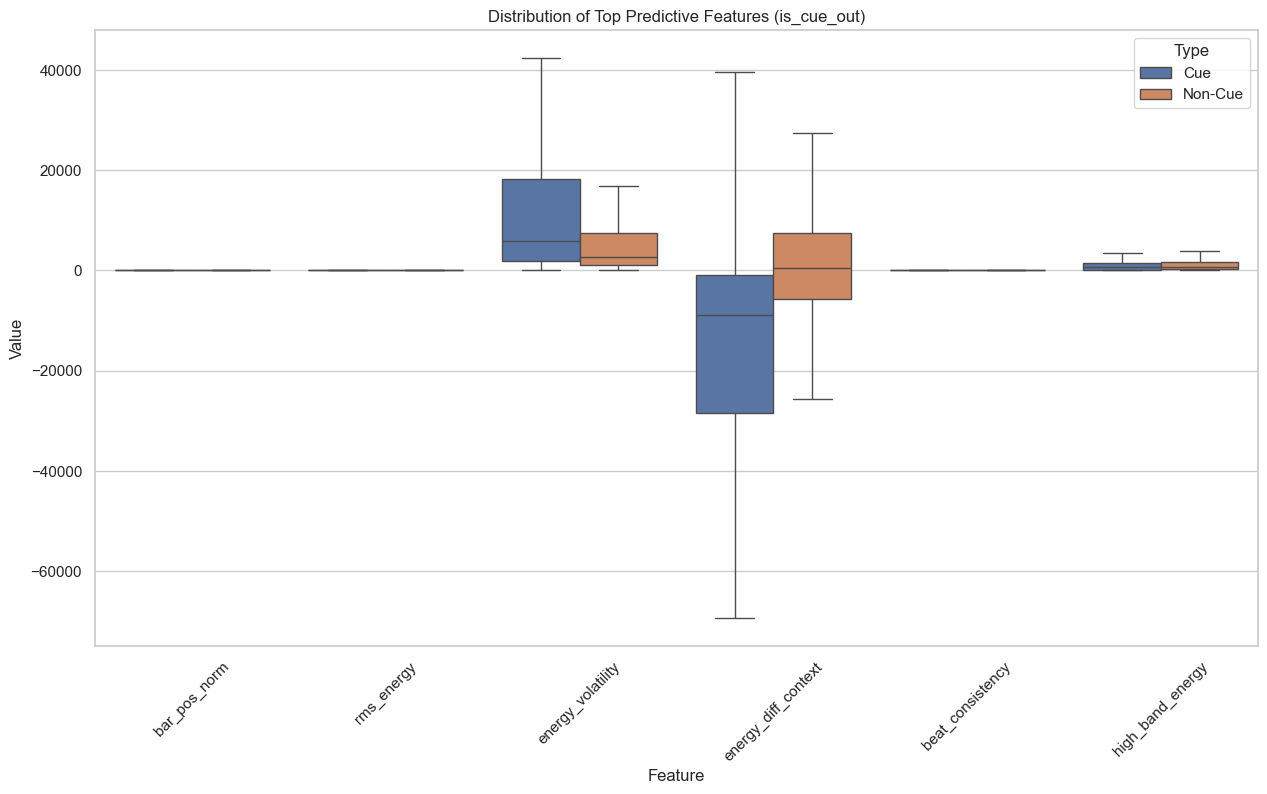

In [8]:
def plot_top_features_dist(df, model, target_col='is_cue_in', n_top=6):
    # Get top features by gain
    booster = model.booster_
    importance = booster.feature_importance(importance_type='gain')
    feature_names = booster.feature_name()
    
    # Sort
    sorted_idx = np.argsort(importance)[::-1]
    top_features = [feature_names[i] for i in sorted_idx[:n_top]]
    
    print(f"Top features for {target_col}: {top_features}")
    
    # Prepare mini dataframe for plotting
    # Sample negatives to reduce plot overhead
    df_pos = df[df[target_col] == 1]
    df_neg = df[df[target_col] == 0].sample(n=len(df_pos)*5, random_state=42)
    df_plot = pd.concat([df_pos, df_neg])
    
    df_plot['Type'] = df_plot[target_col].map({1: 'Cue', 0: 'Non-Cue'})
    
    # Melt
    df_melt = df_plot.melt(id_vars=['Type'], value_vars=top_features, var_name='Feature', value_name='Value')
    
    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df_melt, x='Feature', y='Value', hue='Type', showfliers=False)
    plt.title(f"Distribution of Top Predictive Features ({target_col})")
    plt.xticks(rotation=45)
    plt.show()

# Plot for Cue In
plot_top_features_dist(df, model_in, 'is_cue_in')

# Plot for Cue Out
plot_top_features_dist(df, model_out, 'is_cue_out')

## 6. Correlation Matrix
Check for redundancy among the top features.

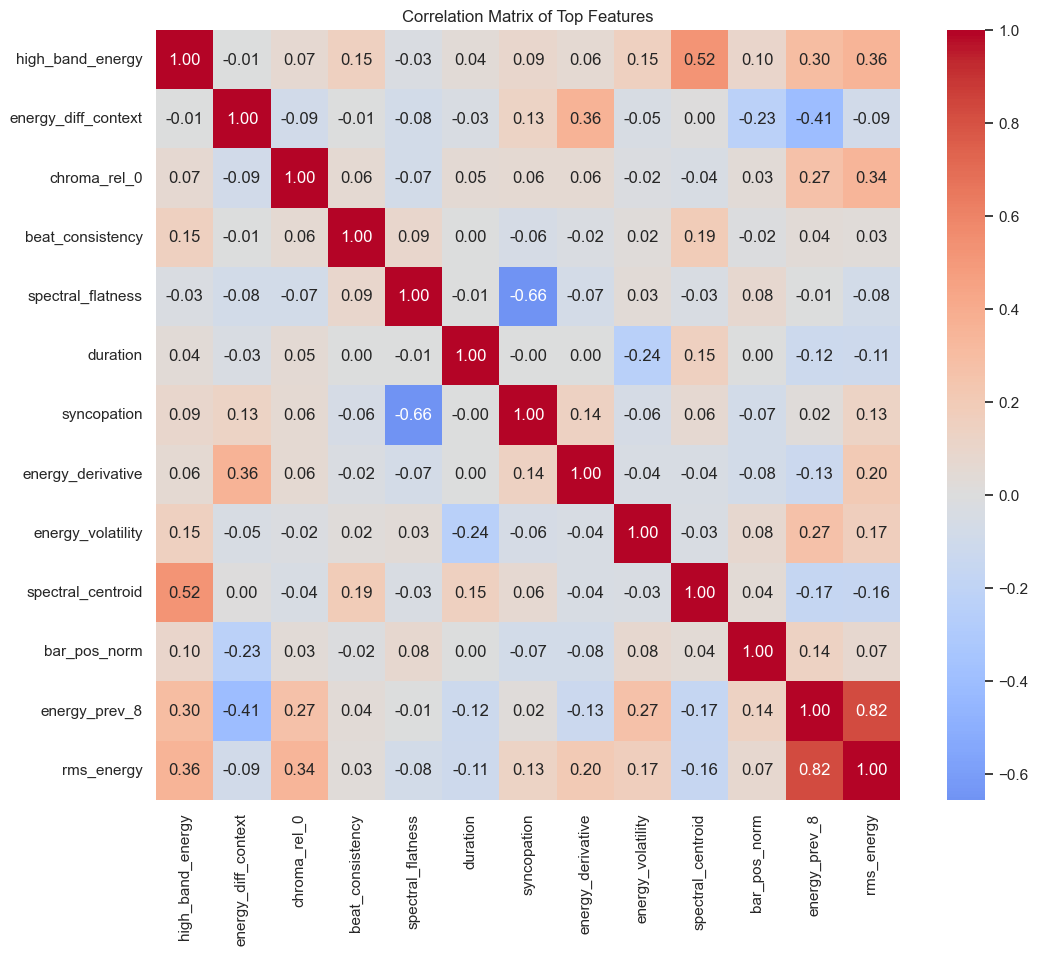

In [9]:
# Collect top features from both models
def get_top_feats(model, n=10):
    imp = model.booster_.feature_importance(importance_type='gain')
    names = model.booster_.feature_name()
    return [names[i] for i in np.argsort(imp)[::-1][:n]]

top_in = get_top_feats(model_in, 8)
top_out = get_top_feats(model_out, 8)
selected_feats = list(set(top_in + top_out))

plt.figure(figsize=(12, 10))
sns.heatmap(df[selected_feats].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation Matrix of Top Features")
plt.show()

## 7. Selected Features Analysis & Recommendation

Based on feature importance results:

### Interpretation
1.  **`bar_pos_norm` (Gain: ~55k)**: This is by far the **dominant** predictor.
    *   *Meaning*: The "where" matters more than the "what". Entry cues are structurally rigid (e.g., almost always at the start or early middle).
2.  **`energy_volatility` & `energy_derivative`**:
    *   *Meaning*: Stability and Change. Cues happen where things stabilize (low volatility) or where transitions occur (builds/drops).
3.  **`beat_strength`**:
    *   *Meaning*: Mix points need a clear beat.
4.  **`chroma_X`** (many of them):
    *   *Meaning*: This is interesting. The model is using specific pitch classes. However, raw chroma bins (`chroma_5`, `chroma_10`) are often just noise unless we normalize them to the key.
    *   *Action*: Since you added `key_tonic`, try to see if that replaces the need for raw chromas, or keep them if you suspect tonal color matters.
5.  **`dist_to_section`**:
    *   *Meaning*: Structural boundary awareness is critical.

### Recommended Feature Set
For your final model, I recommend this trimmed list to avoid noise and overfitting:

**Tier 1: Structural & Positional **
*   `bar_pos_norm` (The king)
*   `dist_to_section`
*   `phrase_pos`
*   `duration`

**Tier 2: Energy & Dynamics**
*   `energy_volatility`
*   `energy_derivative`
*   `mid_band_energy` (Melodic content presence)
*   `beat_strength` (Rhythmic clarity)

**Tier 3: Musical Content**
*   `vocal_conf` (Avoid vocals for entry)
*   `harmonic_ratio` (Tonal vs Percussive)
*   `spectral_flatness` (Noise vs Tone)

**Tier 4: Context (Optional/Experimental)**
*   `vocal_onset_like` (Predicting future vocals is powerful for exit cues, maybe entry too)

**Features to Consider Dropping:**
*   **Raw `chroma_0`...`chroma_11`**: unless you do specific key-invariant transformation. They might overfit to specific songs in your small dataset.
*   **`beat_consistency`**: If it correlates highly with `beat_strength`, drop it.
